# Personal Information
Name: **Jan Grove**

Student ID: **15686604**

Email: [**jan.grove@student.uva.nl**](jan.grove@student.uva.nl)

Submitted on: **23.03.2025**

# Data Context
Barrett's esophagus (BE) is a precursor to esophageal adenocarcinoma (EAC), a malignancy characterized by low five-year survival rates. In light of its clinical severity, a Dutch national digital review panel was established to systematically evaluate dysplasia grades using histopathological whole slide images (WSI). The diagnostic process involves individual assessments by an expert panel, followed by a potential consensus decision for cases of low agreement that ultimately seves as the final medical diagnosis.<br>
The data explored in this analysis comprises said diagnoses. The general objective of the thesis is to select well-performing pathologists and facilitate the development of a classification network, improving prediction performance as well as enabling uncertainty estimates, thereby adressing limitations of a supervised learning approach, that solely focuses on the consensus.

# Data Description

The supplied dataset consists of a case identifier, an initial diagnosis from the hospital, where the patient first seeked help, the consensus diagnosis and individual diagnoses of 20 pathologists. Not every pathologist diagnoses every case, introducing a substantial amount of NaN-values in the pathologist-columns. Case identifiers are comprised of a numerical part which indicates the patient identifier and a roman numeral signalizing the block identifier. After data cleaning and preprocessing, 1980 cases remain. To derive the final medical consensus given several blocks of a patient, the diagnoses will be formed by selecting the highest diagnosis over all blocks per patient.<br>
Each diagnosis is indicated by a numeric label. The labels correspond to the following diagnoses: 
- 1: Non-dysplastic Barret's Esophagus **(NDBE)** - 0.1-0.5\% yearly chance to develop EAC, but still prompts surveillance in 3-5 year intervals;
- 2: Indefinite for Dysplasia **(IND)** - cannot confidently be classified as dysplastic or non-dysplastic due to inflammation or other confounding factors;
- 3: Low-Grade Dysplasia **(LGD)** - 9-13\% chance per year to develop EAC, with diagnosis warranting endoscopic treatment as well as yearly surveillance;
- 4: High-Grade Dysplasia **(HGD)** - pre-cancerous stage, that warrants different treatments, including endoscopic or surgical, and surveillance every 3 months.


### Imports

In [17]:
import numpy as np
import pandas as pd
import krippendorff as kd
import roman
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from matplotlib import colormaps
import warnings

warnings.filterwarnings("ignore")


### Data Loading

In [18]:
data = pd.read_excel("data/cleaned_data_biopsy level_all_pathologists_FINAL-1-1173.xlsx", index_col=0)
data.head(5)

,Case,Referral diagnosis biopsy level,GS biopsy level,Path1,Path2,Path3,Path4,Path5,Path6,Path7,...,Path11,Path12,Path13,Path14,Path15,Path16,Path17,Path18,Path19,Path20
0,1-I,1,1,1,1,1,3,1,1,1,...,1,1,1,0,3,1,2,3,1,1
1,1-II,2,2,1,2,3,1,3,3,1,...,2,3,3,0,3,3,2,3,2,2
2,1-III,1,1,1,1,1,1,1,1,2,...,3,1,1,0,3,1,2,2,1,1
3,2-I,2,1,1,1,1,3,2,1,1,...,1,2,1,0,3,2,1,3,1,1
4,3-II,2,3,3,3,3,3,4,3,3,...,3,3,1,0,3,4,1,4,3,3


In [19]:
data.rename(columns={"Case": "case", "Referral diagnosis biopsy level": "initial dx", "GS biopsy level": "consensus dx"}, inplace=True)


i = 0
for col in data.columns[data.columns.str.contains("Path")]:
    i += 1
    data.rename({col: f"path_{i}_dx"}, axis=1, inplace=True)

In [20]:
data.describe()

,initial dx,consensus dx,path_1_dx,path_2_dx,path_3_dx,path_4_dx,path_5_dx,path_6_dx,path_7_dx,path_8_dx,...,path_11_dx,path_12_dx,path_13_dx,path_14_dx,path_15_dx,path_16_dx,path_17_dx,path_18_dx,path_19_dx,path_20_dx
count,2204.000000,2204.000000,2204.000000,2204.000000,2204.000000,2204.000000,2204.000000,2204.000000,2204.00000,2204.000000,...,2204.000000,2204.000000,2204.000000,2204.000000,2204.000000,2204.000000,2204.000000,2204.000000,2204.000000,2204.000000
mean,2.148820,2.130672,1.044011,2.098911,1.836661,0.983666,0.961887,0.465971,1.27677,0.475499,...,1.535844,1.481851,1.439655,0.713249,1.320327,1.112523,0.940109,0.753630,0.913793,0.540835
std,0.922603,1.069183,1.238791,1.108388,1.329712,1.295863,1.241000,0.950535,1.27996,1.054071,...,1.390939,1.385070,1.357378,1.233658,1.231278,1.358902,1.268368,1.255622,1.235652,1.005506
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,2.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,1.00000,0.000000,...,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.000000,3.000000,2.000000,3.000000,3.000000,2.000000,2.000000,0.000000,3.00000,0.000000,...,3.000000,3.000000,3.000000,1.000000,3.000000,2.000000,2.000000,1.000000,2.000000,1.000000
max,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.00000,4.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2204 entries, 0 to 2203
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   case          2204 non-null   object
 1   initial dx    2204 non-null   int64 
 2   consensus dx  2204 non-null   int64 
 3   path_1_dx     2204 non-null   int64 
 4   path_2_dx     2204 non-null   int64 
 5   path_3_dx     2204 non-null   int64 
 6   path_4_dx     2204 non-null   int64 
 7   path_5_dx     2204 non-null   int64 
 8   path_6_dx     2204 non-null   int64 
 9   path_7_dx     2204 non-null   int64 
 10  path_8_dx     2204 non-null   int64 
 11  path_9_dx     2204 non-null   int64 
 12  path_10_dx    2204 non-null   int64 
 13  path_11_dx    2204 non-null   int64 
 14  path_12_dx    2204 non-null   int64 
 15  path_13_dx    2204 non-null   int64 
 16  path_14_dx    2204 non-null   int64 
 17  path_15_dx    2204 non-null   int64 
 18  path_16_dx    2204 non-null   int64 
 19  path_17_dx 

### Data Cleaning and Preprocessing

Some case identifiers contain an old naming convention that specifies returning visits of patients. It was decided to remove returning visits and keep only the first visit of each patient.

In [22]:
double_visits = data.loc[data["case"].str.contains("_")]
double_visits = double_visits.loc[double_visits["case"].str.contains("_1") == False]
data = data.drop(double_visits.index)
data.loc[data["case"].str.contains("_"), "case"] = data.loc[data["case"].str.contains("_"), "case"].str.replace("_1", "")

During other initial preprocessing steps, an error occured due to a case identifier including "1.5" in the place of the block identifier. Consequently, this row was dropped due to the unclear circumstances under which that identifier was chosen.

In [23]:
data = data[data["case"].str.contains("-1.5") == False]

As analyses will be carried out on both a patient and block level, the case identifier is split into block and patient columns that ease grouping or aggregations.

In [24]:
data["patient"] = data["case"].str.split("-").str[0].astype(int)
data["block"] = data["case"].str.split("-").str[1].str.strip().apply(roman.fromRoman)
data[["case", "block", "patient"]]

,case,block,patient
0,1-I,1,1
1,1-II,2,1
2,1-III,3,1
3,2-I,1,2
4,3-II,2,3
...,...,...,...
2199,1171-I,1,1171
2200,1172-I,1,1172
2201,1172-II,2,1172
2202,1173-I,1,1173


In the provided dataset, no diagnosis is indicated by a 0. To support usage of native pandas-functions that can be used to describe the data, 0s will be converted to np.nan-values. Also, agreement measures between raters, that natively handle missing values (e.g., Krippendorff's alpha coefficient), require a missing-value format.

In [25]:
data.replace(0, np.nan, inplace=True)

To access features of interest more easily during the analysis, a list containing all columns of pathologist diagnoses is created.

In [26]:
pathologists = data.columns[data.columns.str.contains("path")]

In [69]:
non_null_counts = data[pathologists].notnull().sum(axis=1)
non_null_counts.max()

18

### Colormaps

To support understanding of the following visualizations, colormaps are defined in this section. Both a sequential and a divergent colormap are defined to account for different visualization cases.

#### sequential

As a sequential colormap, a custom colormap was created. Other than similar matplotlib-native colormaps, this colormap ranges from **pure** white for low values (0) to 'mediumblue' for high values (1), which is also used in the divergent colormap described below. This colormap will be used for value ranges without a distinct center point.

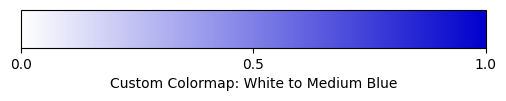

In [27]:
from matplotlib.colors import LinearSegmentedColormap

seq_cm = LinearSegmentedColormap.from_list('custom_blues', ['white', 'mediumblue'])

fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)
norm = mcolors.Normalize(vmin=0, vmax=1)
cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=seq_cm), cax=ax, orientation='horizontal')
cb.set_label('Custom Colormap: White to Medium Blue')
cb.set_ticks([0, 0.5, 1])
plt.show()

#### divergent

The chosen divergent colormap 'bwr' is intended for usage in cases with a distinct center point. To offer a more intuitive interpretation, the colormap is reversed to indicate low values (-1 to 0) in increasingly saturated red and high values (0 to 1) in blue. 

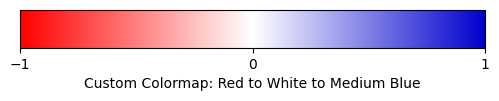

In [28]:
from matplotlib.colors import LinearSegmentedColormap

div_cm = LinearSegmentedColormap.from_list('custom_red_white_blue', ['red', 'white', 'mediumblue'])

fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)
norm = mcolors.Normalize(vmin=-1, vmax=1)
cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=div_cm), cax=ax, orientation='horizontal')
cb.set_label('Custom Colormap: Red to White to Medium Blue')
cb.set_ticks([-1, 0, 1])
plt.show()

### Participation of Pathologists
Here, as pathologists supply diagnoses for all blocks of one patient at a time, cases are max-aggregated by patient. Subsequently, rater participation is encoded into a binary label, indicating whether or not a pathologist participated in the diagnosis of a particular case. The encoded results are displayed in a matrix visualization. The visualization shows how some pathologists have stopped participating in the LANS-panel or have started doing so long after the panel was tasked with its first diagnoses. Due to the non-overlapping nature of pathologists 6 and 20 with several other pathologists, a pairwise agreement measure between those pathologist can not be applied, as shown in the latter part of the dataset exploration.

In [29]:
data_max_aggregated = data.drop(["case", "block"], axis=1).groupby("patient").max()

In [30]:
data_max_aggregated

,initial dx,consensus dx,path_1_dx,path_2_dx,path_3_dx,path_4_dx,path_5_dx,path_6_dx,path_7_dx,path_8_dx,...,path_11_dx,path_12_dx,path_13_dx,path_14_dx,path_15_dx,path_16_dx,path_17_dx,path_18_dx,path_19_dx,path_20_dx
patient,,,,,,,,,,,,,,,,,,,,,
1,2,2,1.0,2.0,3.0,3.0,3.0,3.0,2.0,NaN,...,3.0,3.0,3.0,NaN,3.0,3.0,2.0,3.0,2.0,2.0
2,2,1,1.0,1.0,1.0,3.0,2.0,1.0,1.0,NaN,...,1.0,2.0,1.0,NaN,3.0,2.0,1.0,3.0,1.0,1.0
3,2,3,3.0,3.0,3.0,3.0,4.0,3.0,3.0,NaN,...,3.0,3.0,1.0,NaN,3.0,4.0,1.0,4.0,3.0,3.0
4,2,4,4.0,4.0,3.0,3.0,4.0,4.0,3.0,NaN,...,4.0,3.0,4.0,NaN,3.0,4.0,4.0,NaN,4.0,4.0
5,3,1,1.0,1.0,1.0,3.0,2.0,1.0,3.0,NaN,...,3.0,3.0,3.0,NaN,3.0,3.0,2.0,2.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1169,3,3,NaN,3.0,3.0,NaN,3.0,NaN,3.0,3.0,...,3.0,NaN,3.0,3.0,2.0,3.0,NaN,3.0,NaN,NaN
1170,3,2,NaN,2.0,3.0,NaN,2.0,NaN,2.0,2.0,...,2.0,NaN,2.0,3.0,3.0,3.0,NaN,3.0,NaN,NaN
1171,2,1,NaN,1.0,2.0,NaN,1.0,NaN,1.0,2.0,...,1.0,NaN,1.0,3.0,1.0,1.0,NaN,1.0,NaN,NaN


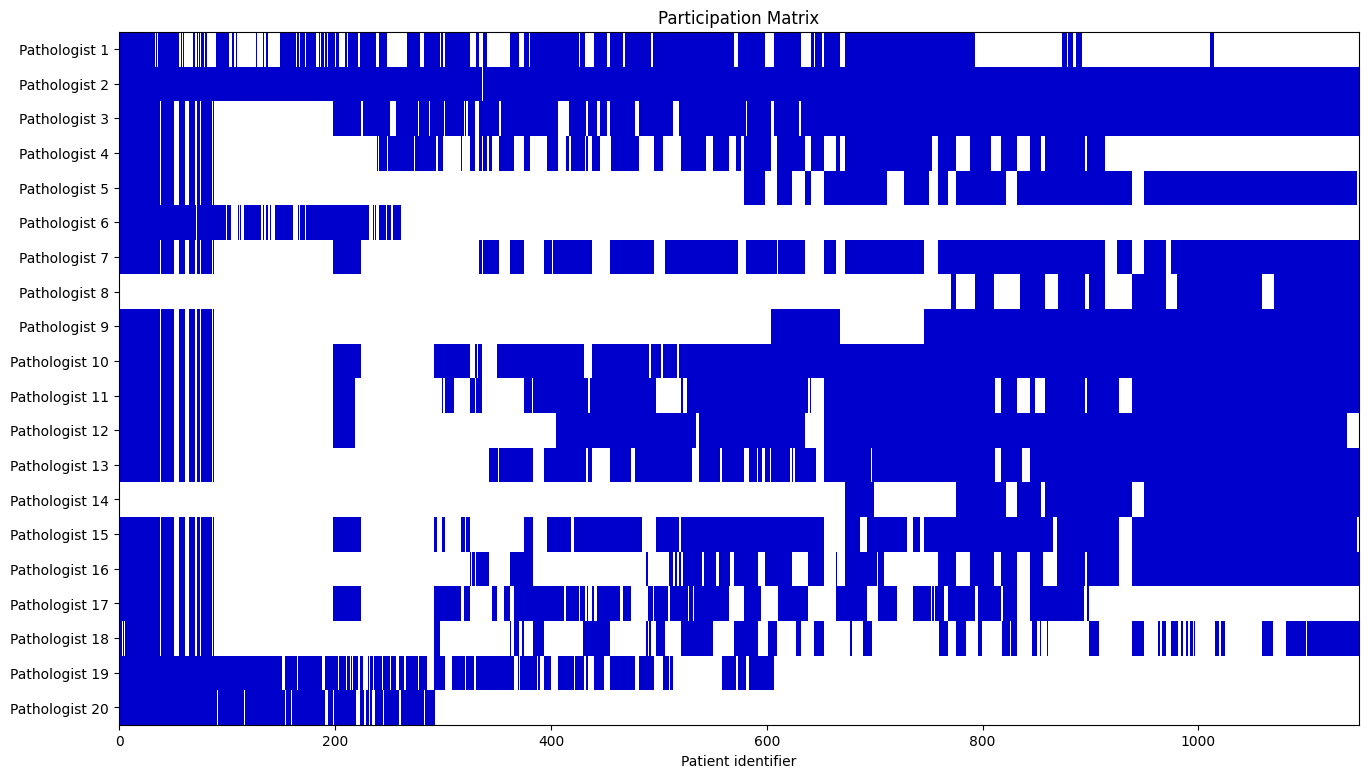

In [31]:
df_rater = data_max_aggregated[pathologists]
rater_participation = (~df_rater.isna()).astype(int)

plt.figure(figsize=(16, 9))
plt.imshow(rater_participation.T, aspect='auto', cmap=seq_cm, interpolation='nearest')
plt.xlabel('Patient identifier')
plt.yticks(ticks=np.arange(len(pathologists)), labels=[f'Pathologist {i+1}' for i in range(len(pathologists))])
plt.title('Participation Matrix')
plt.show()

Also, the percentage of cases in which each pathologist was involved was calculated. The average number of patients, 471.3, corresponds to roughly 46% of cases graded. Pathologist 2 stands out due to having diagnoses around 98% of patients, with the second highest participation rate being ~73% of pathologist 3.

In [32]:
total_cases = len(rater_participation)
rater_counts = rater_participation.sum()
participation_rate = rater_counts / total_cases * 100

rater_summary = pd.DataFrame({
    'absolute number of ratings': rater_counts,
    'ratio of rated patients': participation_rate
})

print(f"number of patients: {total_cases}")
print(rater_summary.sort_values('ratio of rated patients', ascending=False))
print(f"avg number of ratings per case: {rater_counts.mean():.2f}")
print(f"median number of ratings per case: {rater_counts.median():.2f}")

number of patients: 1149
            absolute number of ratings  ratio of rated patients
path_2_dx                         1148                99.912968
path_3_dx                          972                84.595300
path_10_dx                         924                80.417755
path_12_dx                         809                70.409051
path_11_dx                         806                70.147955
path_13_dx                         805                70.060923
path_15_dx                         802                69.799826
path_7_dx                          783                68.146214
path_1_dx                          619                53.872933
path_16_dx                         589                51.261967
path_5_dx                          555                48.302872
path_9_dx                          541                47.084421
path_4_dx                          539                46.910357
path_17_dx                         530                46.127067
path_19_dx     

### Similarity between Blocks
Informing a decision on whether to use max-aggregated or individual block data, agreement between blocks is investigated. To assess similarity, Krippendorff's alpha coefficient is employed, natively handling nan-values and taking similarities/agreement by chance into account.

In [33]:
block_data_rater = data.drop(["case", "initial dx"], axis=1)

block_correlation = pd.DataFrame(columns=["Krippendorff"])
for patient in block_data_rater["patient"].unique():
    patient_data = block_data_rater[block_data_rater["patient"] == patient].drop(["patient", "block"], axis=1)
    if patient_data.shape[0] > 1: 
        corr = pd.DataFrame(kd.alpha(patient_data.values, level_of_measurement="nominal", value_domain=[np.nan, 1.0, 2.0, 3.0, 4.0]), columns=["Krippendorff"], index=[patient])
        block_correlation = pd.concat([block_correlation, corr])

block_correlation.dropna(inplace=True)

After having calculated the correlations between blocks of one patient, the correlations are displayed in a box-plot. While values range from 1 (perfect agreement) to -1 (bad agreement), the median (Q2) and IQR (Q3 - Q1) concentrates around 0 (agreement by chance), indicating no correlation. This verifies that using individual blocks for further analyses is not biased through their connection to the same patient, but rather that different blocks of the same patient can cause different diagnostic results.

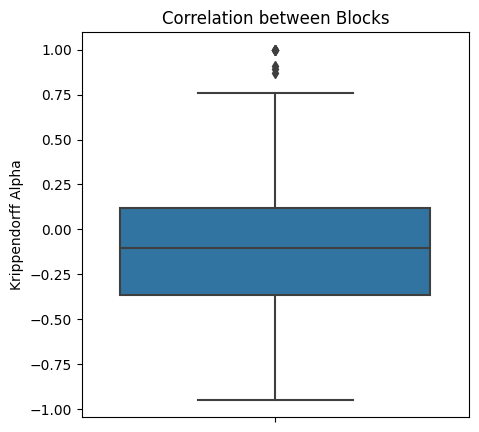

In [34]:
plt.figure(figsize=(5, 5))
sns.boxplot(y=block_correlation['Krippendorff'])
plt.title('Correlation between Blocks')
plt.ylabel('Krippendorff Alpha')
plt.show()

### Inter-Rater Agreement
Similarly to block agreement, inter-rater agreement is evaluated using Krippendorff's alpha coefficient. The agreement offers insights into how similar diagnoses of different pathologists are. To supply insights into the agreement, pairwise agreement between all pathologists as well as the mean agreement of each pathologist will be visualized for both max-aggregated cases and individual block-level cases. Furthermore, differences between the two approaches will be compared.

As the participation matrix displayed earlier showed differences in the overlap of pathologists (thus commonly rated cases), the correlation matrices will contain the agreement as well as the number of common rows to better interpret the plots. Therefore, a custom function is defined to annotate the heatmap accordingly. For the comparison of the two approaches, no indication of common rows is provided.

In [35]:
def annotate_heatmap(data, number_of_common_rows):
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            plt.text(j + 0.5, i + 0.5, f'{data[i, j]:.2f}\n({int(number_of_common_rows[i, j])})', 
                        color='black', ha='center', va='center')
            
def annotate_withoutcommon(data):
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if not np.isnan(data.iloc[i, j]):
                plt.text(j + 0.5, i + 0.5, f'{data.iloc[i, j]:.2f}', ha='center', va='center', color='black')


#### Max-Aggregation-Level

To first generate the agreement data, two contingency table-like dataframes are created, storing the agreement and the number of common rows respectively. The number of common rows is then inferred by computing the length of the dataframe with any rows including nan-values dropped. As described, agreement is calculated using Krippendorff's alpha for nominal data. This approach will be adapted for block-level data.

In [36]:
pairwise_corr = pd.DataFrame(columns=[pathologists], index=[pathologists])
number_of_common_rows = pd.DataFrame(columns=[pathologists], index=[pathologists])
for i in pathologists:
    for j in pathologists:
        pairwise_df = data_max_aggregated[[i, j]]
        number_of_common_rows.loc[i,j] = len(pairwise_df.dropna())
        if len(pairwise_df[pairwise_df.isna().any(axis=1)]) == len(pairwise_df):
            pairwise_corr.loc[i,j] = np.nan
        else:
            pairwise_corr.loc[i,j] = kd.alpha(pairwise_df.T.values, level_of_measurement="nominal", value_domain=[np.nan, 1.0, 2.0, 3.0, 4.0])

The agreement matrix below portrays several nan-values, indicating no or a maximum of 1 common rows between the given pathologists. Overall, agreement varies between raters with some rows - e.g., pathologist 15 - exhibiting generally lower agreements than for example pathologist 2. Pathologist 1 and 14 or 5 and 19 show poor agreement, but a low number of common cases at the same time. In contrast to that, pathologist 6 and 4 or 2 and 3 demonstrate the highest agreements with 0.6 and 0.59 respectively - though the prior is based on just 16 cases.

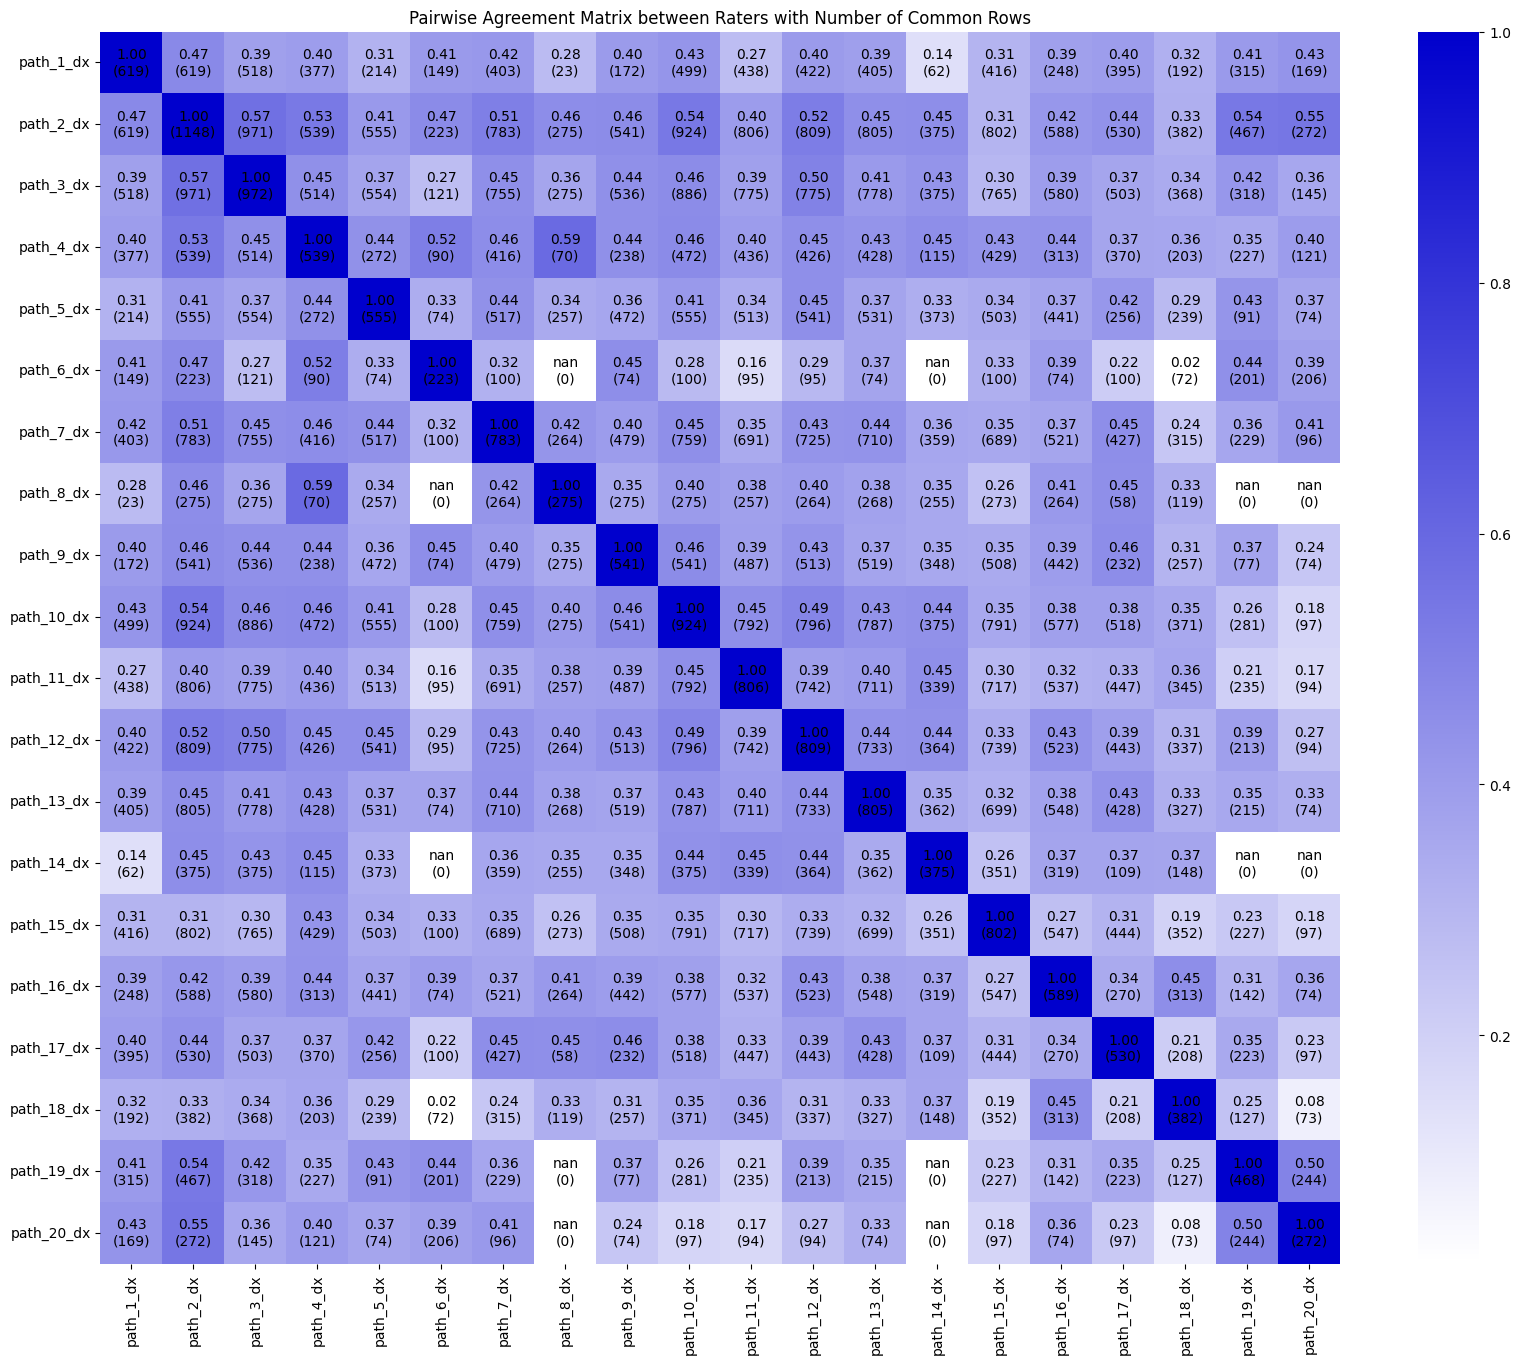

In [37]:
plt.figure(figsize=(20, 16))
sns.heatmap(pairwise_corr.astype(float), annot=False, cmap=seq_cm, cbar=True)
annotate_heatmap(pairwise_corr.values, number_of_common_rows.values)
plt.ylabel("")
plt.xlabel("")
plt.title('Pairwise Agreement Matrix between Raters with Number of Common Rows')
plt.show()

Gaining a more general insight, the mean pairwise agreement for the max-aggregated diagnoses is portrayed below. The color of the bars symbolized the mean number of common rows with other pathologists. Pathologist 2 performs best and also exhibits the most mean common rows. Contrastingly, pathologist 6 performs well when compared to other pathologists' diagnoses but has a low number of common rows with other pathologists. Relating back to the participation matrix, pathologist 6 participated mostly in the earlier cases and has no overlap with several pathologists, leading to their low number of common rows. Pathologist 15 exhibits a contrasting pattern, having a low mean agreement with other raters while having participated in a substantial amount of common cases.  

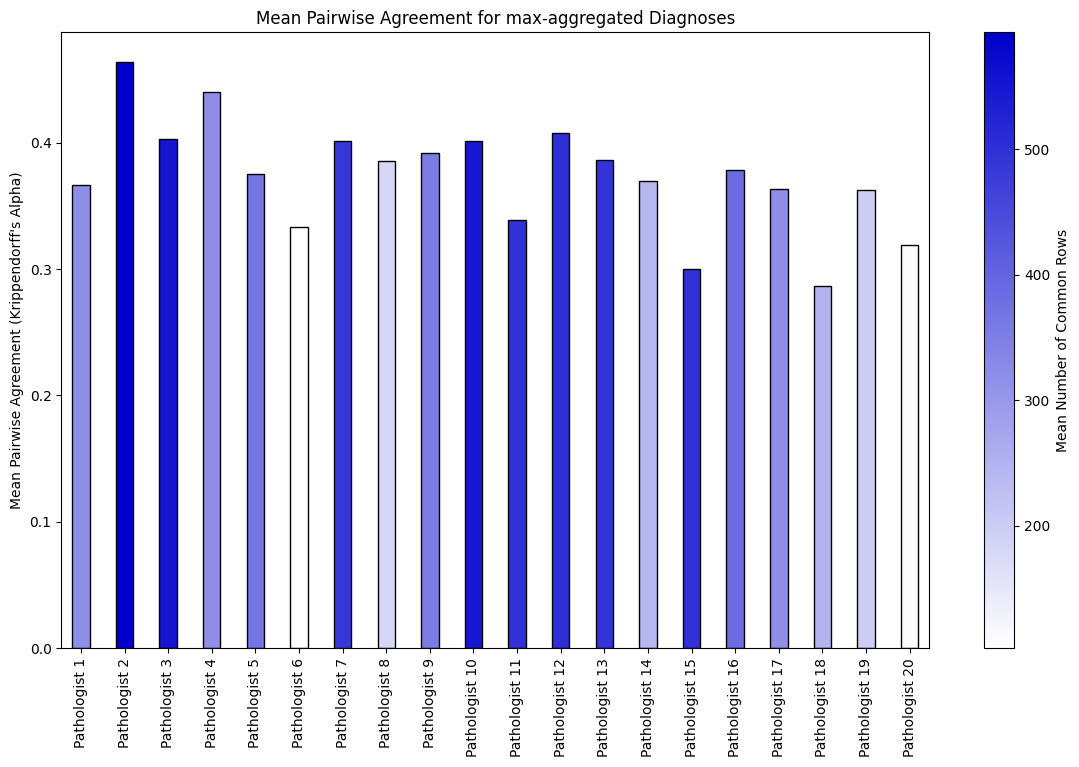

In [38]:
mean_pairwise_corr = pairwise_corr.apply(lambda row: row.drop(row.name).mean(), axis=1)
mean_number_of_common_rows = number_of_common_rows.apply(lambda row: row.drop(row.name).mean(), axis=1)
normalized_common_rows = (mean_number_of_common_rows - mean_number_of_common_rows.min()) / (mean_number_of_common_rows.max() - mean_number_of_common_rows.min())

colors = seq_cm(normalized_common_rows)

fig, ax = plt.subplots(figsize=(14, 8))
bars = mean_pairwise_corr.plot(kind='bar', width=0.4, color=colors, edgecolor='black', ax=ax)

sm = cm.ScalarMappable(cmap=seq_cm, norm=plt.Normalize(vmin=mean_number_of_common_rows.min(), vmax=mean_number_of_common_rows.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Mean Number of Common Rows')

plt.title('Mean Pairwise Agreement for max-aggregated Diagnoses')
plt.ylabel("Mean Pairwise Agreement (Krippendorff's Alpha)")
plt.xticks(ticks=np.arange(len(pathologists)), labels=[f'Pathologist {i+1}' for i in range(len(pathologists))])
plt.show()

#### Block-Level

In [39]:
pairwise_corr_nonagg = pd.DataFrame(columns=[pathologists], index=[pathologists])
number_of_common_rows_nonagg = pd.DataFrame(columns=[pathologists], index=[pathologists])
for i in pathologists:
    for j in pathologists:
        pairwise_df = data[[i, j]]
        number_of_common_rows_nonagg.loc[i,j] = len(pairwise_df.dropna())
        if len(pairwise_df[pairwise_df.isna().any(axis=1)]) == len(pairwise_df):
            pairwise_corr_nonagg.loc[i,j] = np.nan
        else:
            pairwise_corr_nonagg.loc[i,j] = kd.alpha(pairwise_df.T.values, level_of_measurement="nominal", value_domain=[np.nan, 1.0, 2.0, 3.0, 4.0])
            

Without max-aggregation of the data, low agreements such as the low agreement between pathologists 1 and 14 as well as 5 and 19 are still perceptible. High agreement, on the other hand, is visible in more cases such as between pathologist 4 and 6 (0.67, but only 31 cases) or 2 and 20 (0.6 with 606 cases).

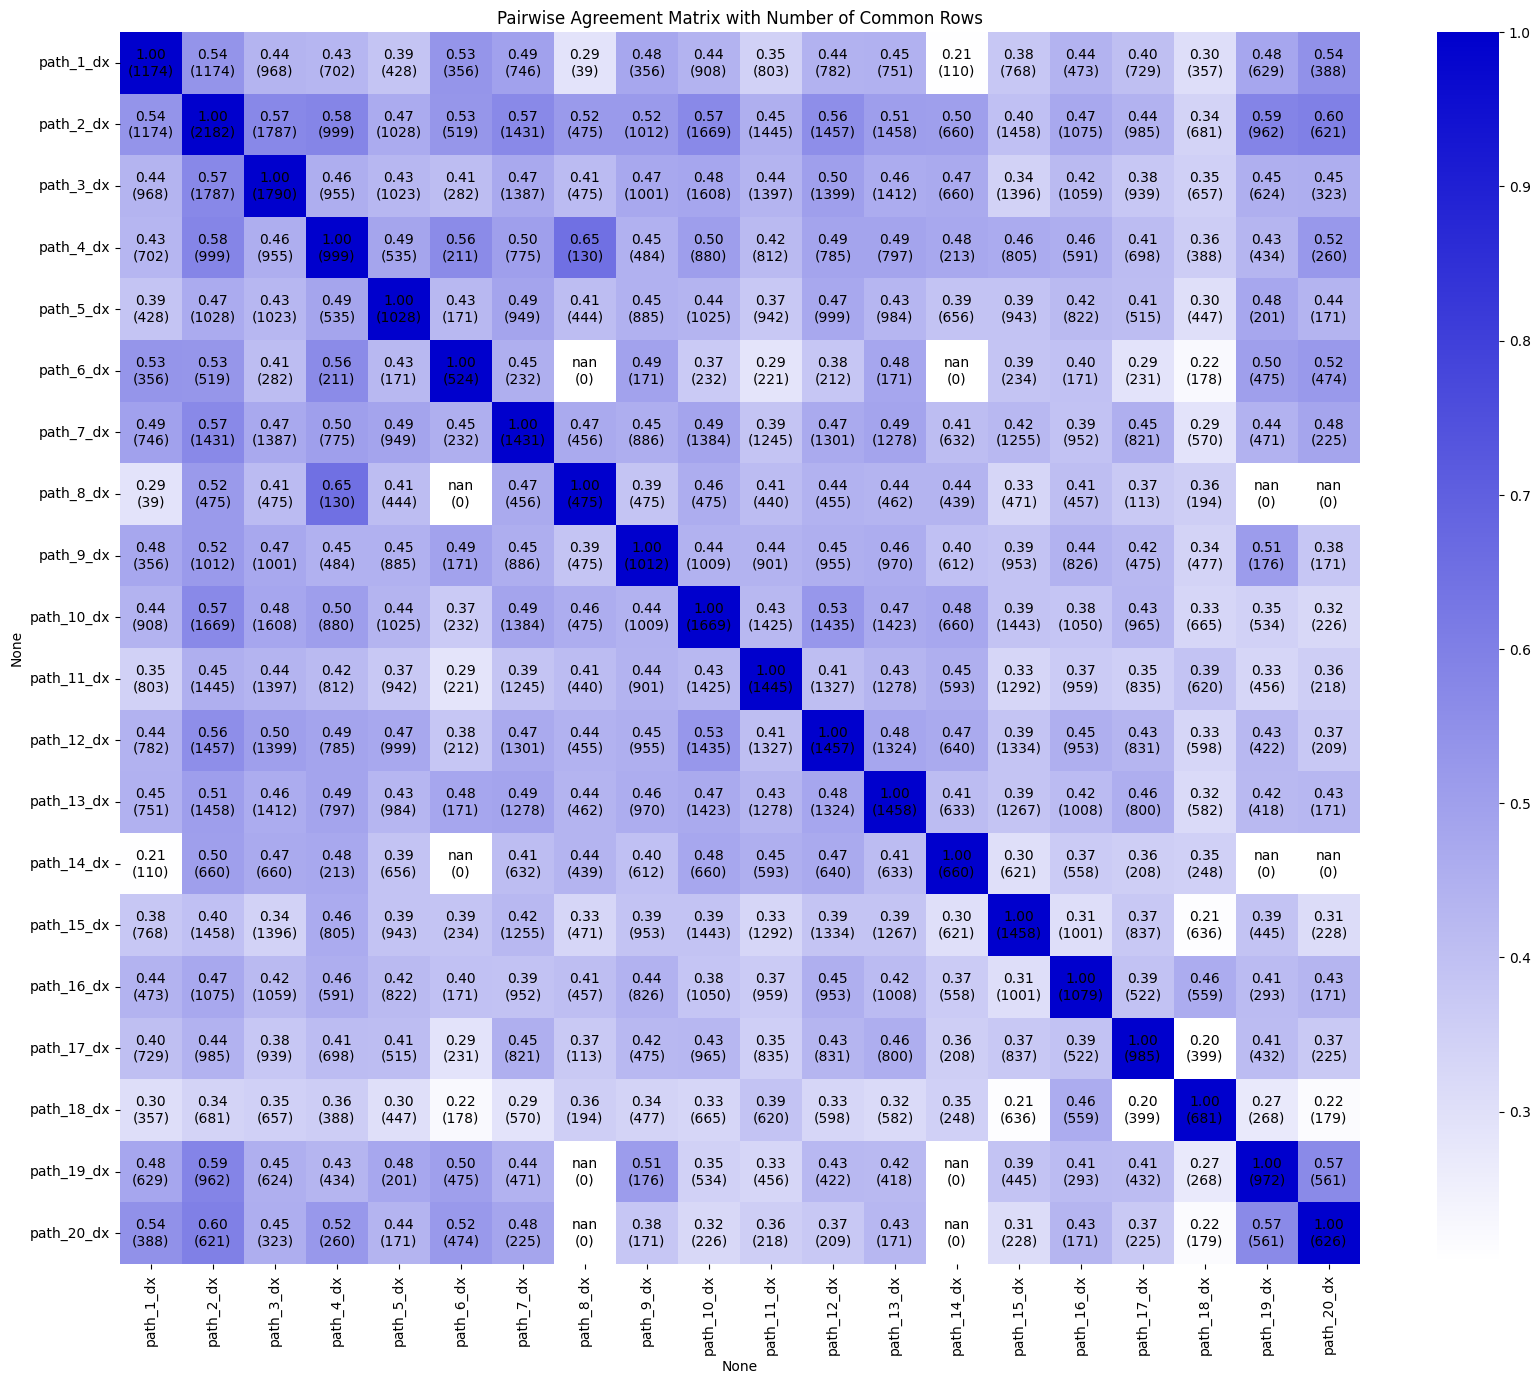

In [40]:
plt.figure(figsize=(20, 16))
sns.heatmap(pairwise_corr_nonagg.astype(float), annot=False, cmap=seq_cm, cbar=True)

annotate_heatmap(pairwise_corr_nonagg.values, number_of_common_rows_nonagg.values)

plt.title('Pairwise Agreement Matrix with Number of Common Rows')
plt.show()

Mean pairwise correlations underline the trend from the aggregated data for the highlighted pathologists 2 and 6. Pathologist 15 performs slightly better relatively to the other pathologists, with pathologist 18 performing discernibly worse and worst overall.

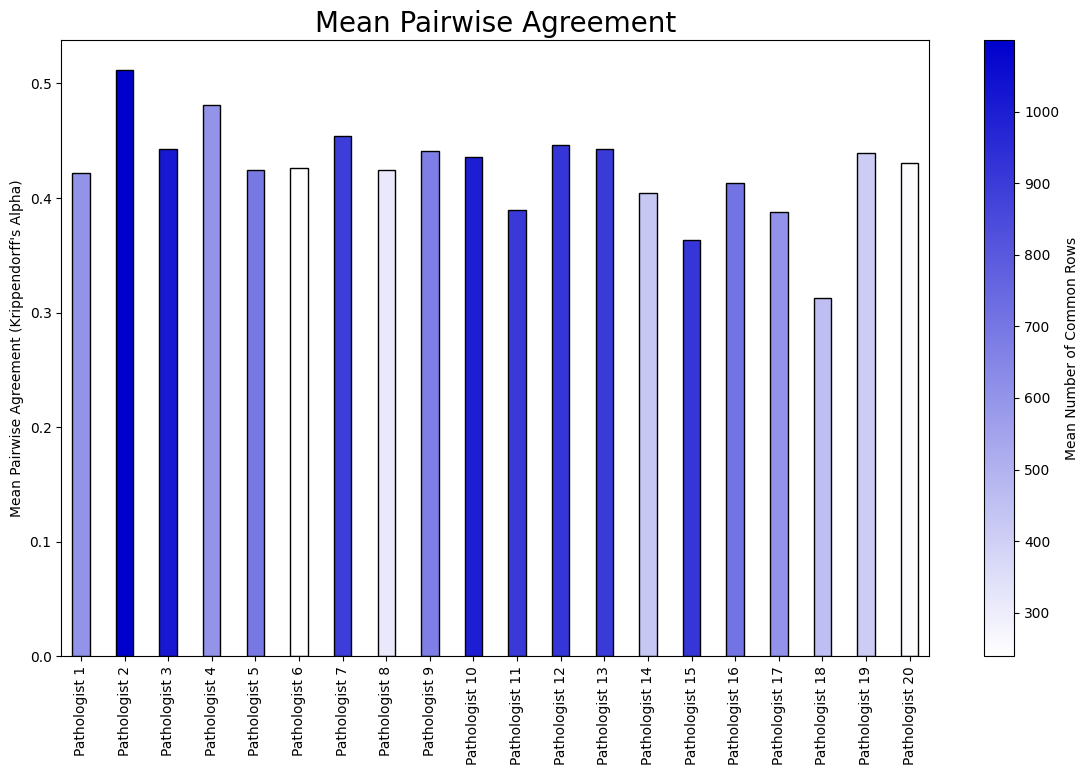

In [78]:
mean_pairwise_corr_nonagg = pairwise_corr_nonagg.apply(lambda row: row.drop(row.name).mean(), axis=1)
mean_number_of_common_rows_nonagg = number_of_common_rows_nonagg.apply(lambda row: row.drop(row.name).mean(), axis=1)
normalized_common_rows_nonagg = (mean_number_of_common_rows_nonagg - mean_number_of_common_rows_nonagg.min()) / (mean_number_of_common_rows_nonagg.max() - mean_number_of_common_rows_nonagg.min())

colors = seq_cm(normalized_common_rows_nonagg)

fig, ax = plt.subplots(figsize=(14, 8))
bars = mean_pairwise_corr_nonagg.plot(kind='bar', width=0.4, color=colors, edgecolor='black', ax=ax)

sm = cm.ScalarMappable(cmap=seq_cm, norm=plt.Normalize(vmin=mean_number_of_common_rows_nonagg.min(), vmax=mean_number_of_common_rows_nonagg.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Mean Number of Common Rows')

plt.title('Mean Pairwise Agreement', fontsize=20)
plt.ylabel("Mean Pairwise Agreement (Krippendorff's Alpha)")
plt.xticks(ticks=np.arange(len(pathologists)), labels=[f'Pathologist {i+1}' for i in range(len(pathologists))])
plt.show()

#### Difference between block-wise and max-aggregated Agreement

In [42]:
corr_differences = pairwise_corr - pairwise_corr_nonagg

Differences between the block-level and max-aggregated agreements are low overall. A few outliers such as differences of -0.14 for pathologists 6 and 20 or - notably - 0.22 for pathologist 9 and 19 are evident.

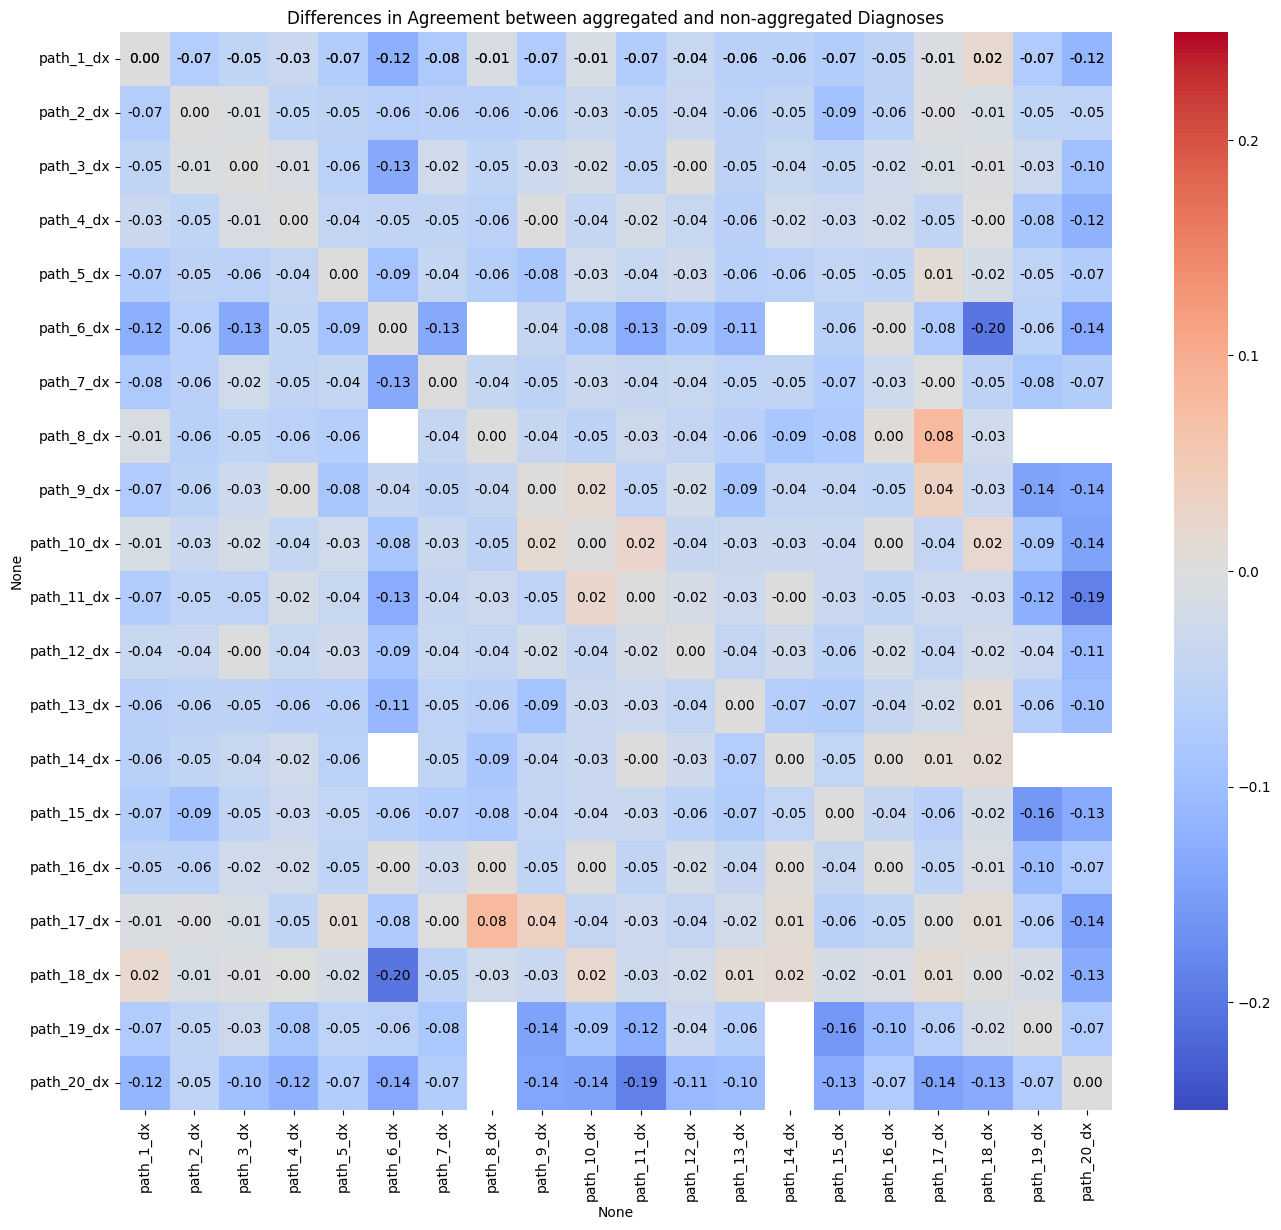

In [43]:
plt.figure(figsize=(16, 14))
sns.heatmap(corr_differences.astype(float), cmap='coolwarm', cbar=True, annot=True, fmt=".2f", annot_kws={"size": 10}, mask=corr_differences.isna(), vmin=-0.25, vmax=0.25)
annotate_withoutcommon(corr_differences)
plt.title('Differences in Agreement between aggregated and non-aggregated Diagnoses')
plt.show()


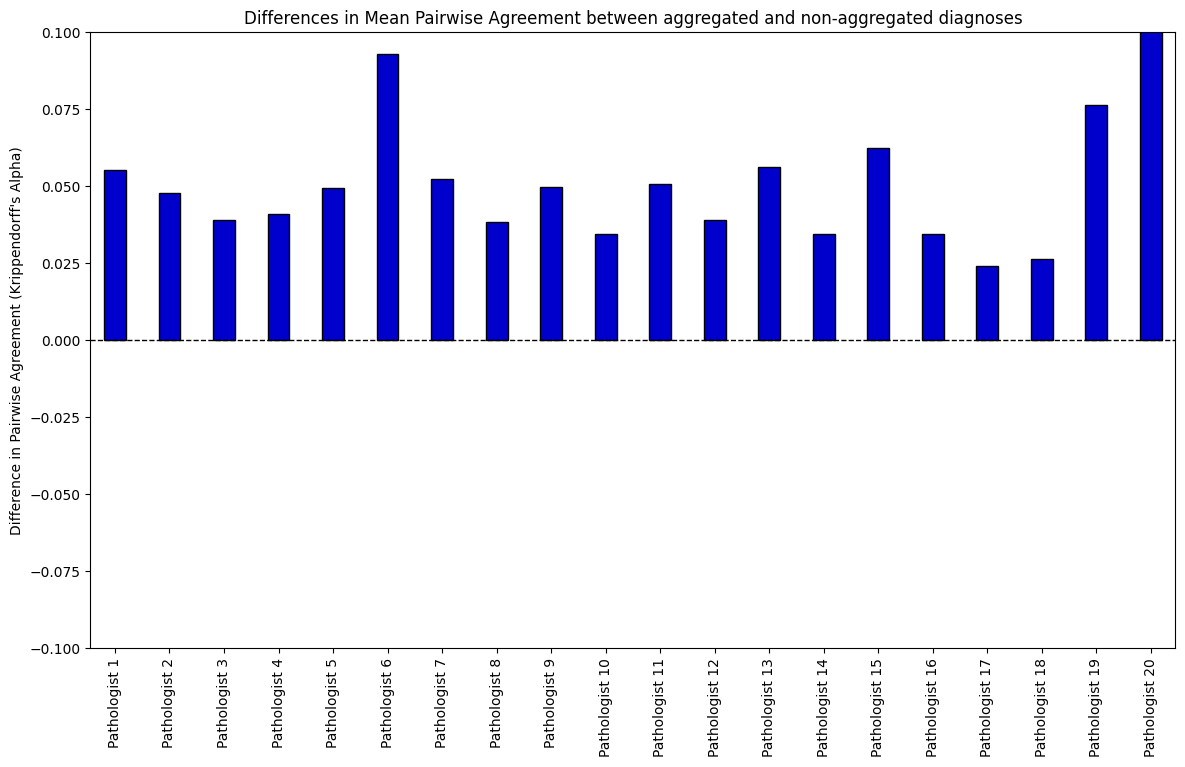

In [44]:
mean_pairwise_corr_diff = mean_pairwise_corr_nonagg - mean_pairwise_corr

fig, ax = plt.subplots(figsize=(14, 8))
bars = mean_pairwise_corr_diff.plot(kind='bar', width=0.4, color=["mediumblue"], edgecolor='black', ax=ax)

ax.axhline(y=0, color='black', linestyle='--', linewidth=1) 

plt.title('Differences in Mean Pairwise Agreement between aggregated and non-aggregated diagnoses')
plt.ylim(-0.1, 0.1)
plt.ylabel("Difference in Pairwise Agreement (Krippendorff's Alpha)")
plt.xticks(ticks=np.arange(len(pathologists)), labels=[f'Pathologist {i+1}' for i in range(len(pathologists))])
plt.show()

### Rater-Consensus Agreement

Agreement between each pathologist and the consensus is displayed for both the max-aggregation and case-level diagnoses. Both visualizations underline the findings of the mean rater correlation plots with pathologist 2 performing best and pathologists 15 and 18 worst. Pathologists 6 performs similarly to pathologists 3, 4, 10, 12, 20, contrasting their results for block-level pairwise agreements. 

In [45]:
participation_rate_norm = (participation_rate - participation_rate.min()) / (participation_rate.max() - participation_rate.min())

#### Max-Aggregation-Level

In [46]:
df_rater_cons = pd.DataFrame(columns=["agreement"], index=[pathologists])
for i in pathologists:
    pairwise_df = data_max_aggregated[["consensus dx", i]]
    if len(pairwise_df[pairwise_df.isna().any(axis=1)]) == len(pairwise_df):
        df_rater_cons.loc[i, "agreement"] = np.nan
    else:
        df_rater_cons.loc[i, "agreement"] = kd.alpha(pairwise_df.T.values, level_of_measurement="nominal", value_domain=[np.nan, 1.0, 2.0, 3.0, 4.0])

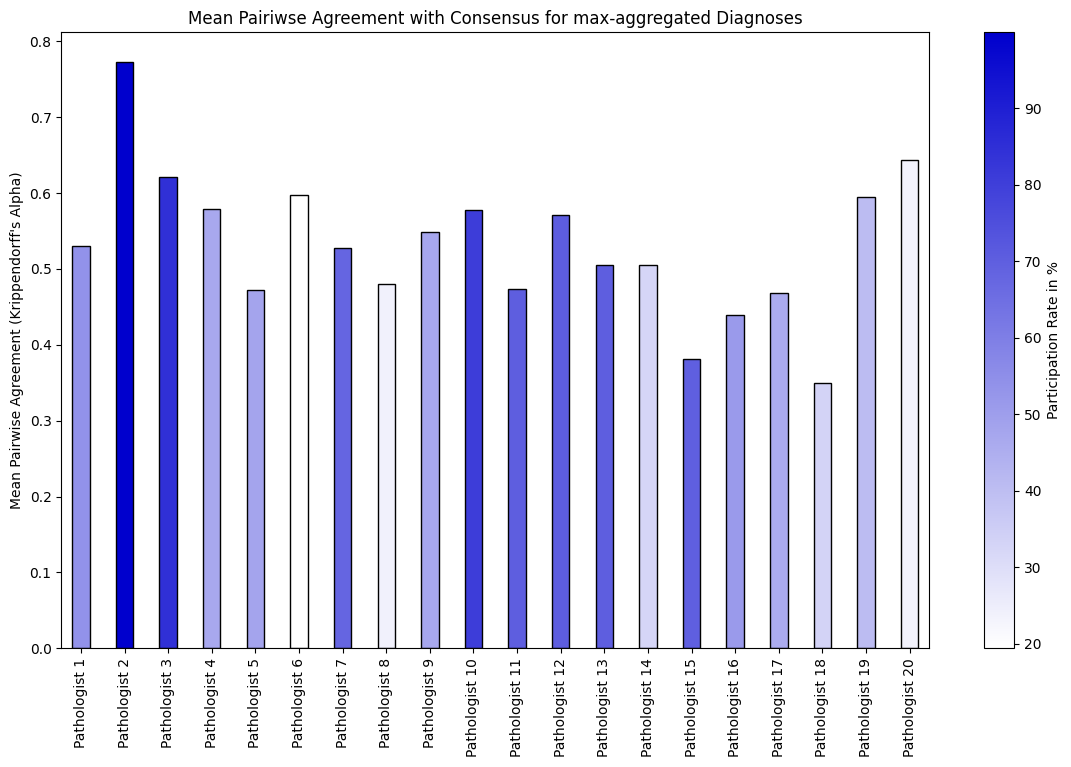

In [47]:
colors = seq_cm(participation_rate_norm.values)

fig, ax = plt.subplots(figsize=(14, 8))
bars = df_rater_cons["agreement"].plot(kind='bar', width=0.4, color=colors, edgecolor='black', ax=ax, legend=False)

sm = cm.ScalarMappable(cmap=seq_cm, norm=plt.Normalize(vmin=participation_rate.min(), vmax=participation_rate.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Participation Rate in %')

plt.title('Mean Pairiwse Agreement with Consensus for max-aggregated Diagnoses')
plt.ylabel("Mean Pairwise Agreement (Krippendorff's Alpha)")
plt.xticks(ticks=np.arange(len(pathologists)), labels=[f'Pathologist {i+1}' for i in range(len(pathologists))])
plt.show()

#### Block-Level

In [48]:
df_rater_cons_nonagg = pd.DataFrame(columns=["agreement"], index=[pathologists])
for i in pathologists:
    pairwise_df = data[["consensus dx", i]]
    if len(pairwise_df[pairwise_df.isna().any(axis=1)]) == len(pairwise_df):
        df_rater_cons_nonagg.loc[i, "agreement"] = np.nan
    else:
        df_rater_cons_nonagg.loc[i, "agreement"] = kd.alpha(pairwise_df.T.values, level_of_measurement="nominal", value_domain=[np.nan, 1.0, 2.0, 3.0, 4.0])

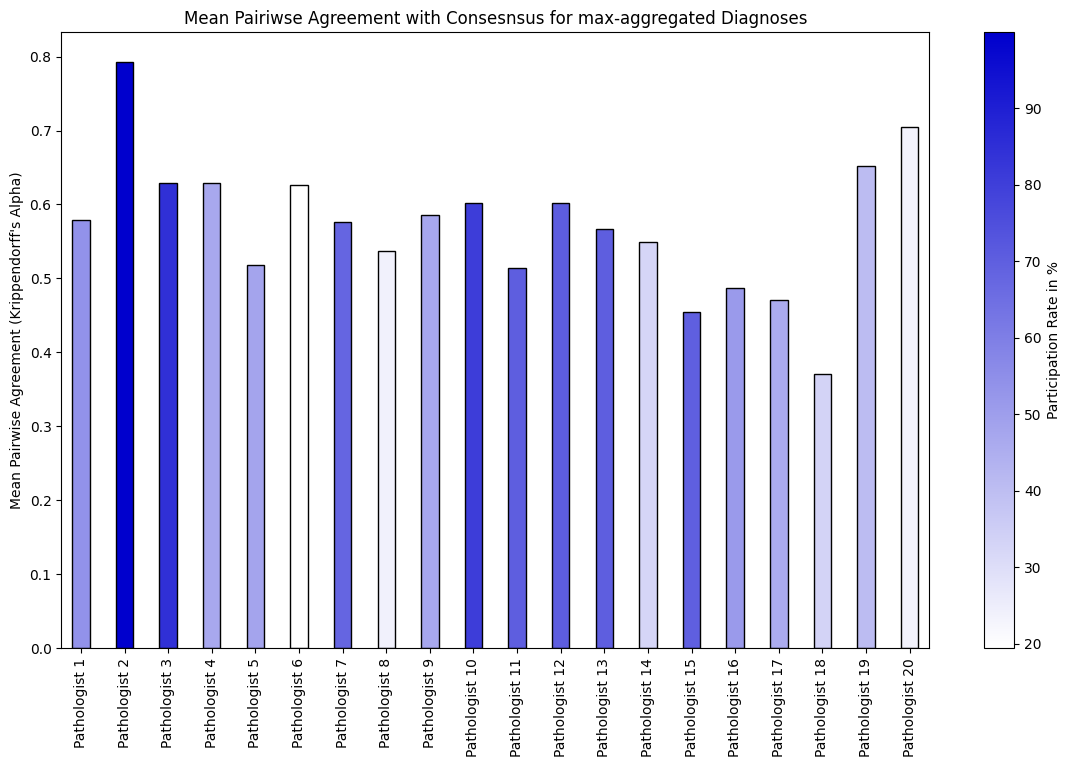

In [49]:
colors = seq_cm(participation_rate_norm.values)

fig, ax = plt.subplots(figsize=(14, 8))
bars = df_rater_cons_nonagg["agreement"].plot(kind='bar', width=0.4, color=colors, edgecolor='black', ax=ax, legend=False)

sm = cm.ScalarMappable(cmap=seq_cm, norm=plt.Normalize(vmin=participation_rate.min(), vmax=participation_rate.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Participation Rate in %')

plt.title('Mean Pairiwse Agreement with Consesnsus for max-aggregated Diagnoses')
plt.ylabel("Mean Pairwise Agreement (Krippendorff's Alpha)")
plt.xticks(ticks=np.arange(len(pathologists)), labels=[f'Pathologist {i+1}' for i in range(len(pathologists))])
plt.show()

### Difficulty per Case Analysis

Assessing the agreement between raters as a form of reliability can be tricky. As agreement is generally lower with more difficult cases, the difficulty of each diagnosis plays a vital role in assessing rater reliability. Therefore, two approaches of evaluating the difficulty of each case - namely percentage agreement with the consensus and the ranges of diagnoses - are employed.

#### Percentage Agreement of Pathologists with final Consensus

To assess the percentage agreement of pathologist rating with the final consensus, for each case, the percentage of pathologist diagnoses that agree with the consensus diagnoses are calculated. Agreements are then portrayed in a box plot.

In [50]:
df_for_difficulty_agreement = data.drop(["initial dx", "patient", "block"], axis=1)
df_for_difficulty_agreement.reset_index(drop=True, inplace = True)

In [51]:
percentage_agreement = pd.DataFrame(columns=["agreement"])

for case_id in data["case"].unique():

    patient_data = df_for_difficulty_agreement.loc[df_for_difficulty_agreement["case"] == case_id].drop(["case"], axis=1)
    patient_data.dropna(axis=1, how="all", inplace=True)

    consensus_rating = patient_data["consensus dx"].values[0]
    value_counts = patient_data.T.value_counts()
    consensus_rating_count = value_counts[consensus_rating] - 1

    ratings_count = patient_data.shape[1] - 1

    corr = pd.DataFrame(data=(consensus_rating_count / ratings_count), columns=["agreement"], index=[case_id])
    percentage_agreement = pd.concat([percentage_agreement, corr])


While the box plot shows a high overall agreement, a median of around 0.8 indicates occurences of more difficult cases with agreement going as low as almost 0 in some cases. This entails the need for further case-to-case analysis to potentially weight reliability measures by the difficulty of cases.

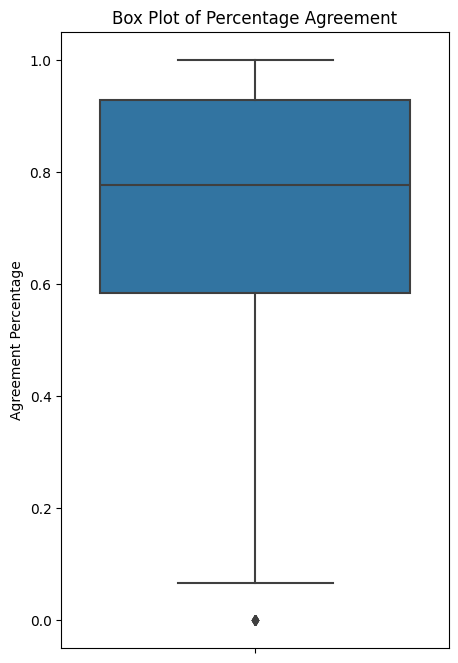

In [77]:
plt.figure(figsize=(5, 8))
sns.boxplot(y=percentage_agreement['agreement'])
plt.title('Box Plot of Percentage Agreement')
plt.ylabel('Agreement Percentage')
plt.show()

#### Ranges of Diagnoses

The ranges of diagnoses also play a role in assessing case difficulty. When diagnoses spans several values, diagnosis can be categorized as more difficult.

In [53]:
df_diagnoses_range = pd.DataFrame()
df_for_ranges = data.drop(["initial dx", "consensus dx", "patient", "block"], axis=1)

In [54]:
for case_id in df_for_ranges["case"].unique():
    case_data = df_for_ranges[df_for_ranges["case"] == case_id].drop(["case"], axis=1)
    case_data.dropna(axis=1, how="all", inplace=True)
    df_diagnoses_range = pd.concat([df_diagnoses_range, pd.DataFrame(case_data.T.value_counts()).T])

df_diagnoses_range.index = df_for_ranges["case"].unique()
df_diagnoses_range.rename(columns={1.0: "1", 2.0: "2", 3.0: "3", 4.0: "4"}, inplace=True)

filtered_ranges = df_diagnoses_range[df_diagnoses_range.isna().sum(axis=1) < 1]
filtered_ranges = filtered_ranges.div(filtered_ranges.sum(axis=1), axis=0) * 100

The presence of 99 rows with the presence of all four possible diagnoses underlines the need for further investigation into case difficulty and weighting of cases.

In [55]:
len(filtered_ranges)

143

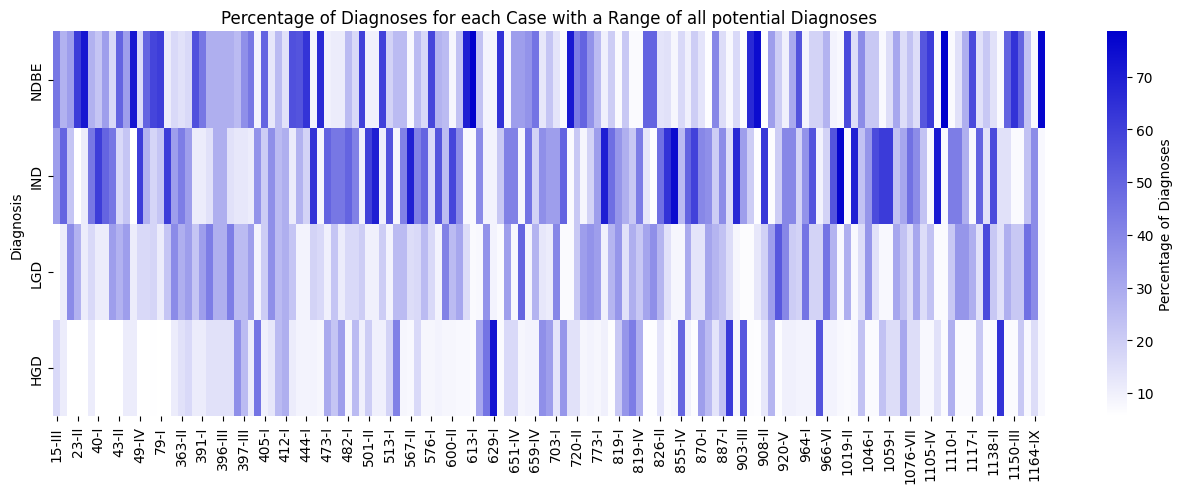

In [56]:
plt.figure(figsize=(16, 5))
sns.heatmap(filtered_ranges.T, cmap=seq_cm, cbar=True)

cbar = plt.gca().collections[0].colorbar
cbar.set_label("Percentage of Diagnoses")

plt.title('Percentage of Diagnoses for each Case with a Range of all potential Diagnoses')
plt.ylabel("Diagnosis")
plt.yticks(ticks=np.arange(4) + 0.5, labels=["NDBE", "IND", "LGD", "HGD"])

plt.show()


### Over- and Undershooting in Diagnoses

Rater reliability is influenced by whether they generally over- or undershoot when diagnosing cases. Therefore, over- and undershooting of is explored.

In [57]:
data_for_overunder = data[data["consensus dx"] != 2]
data_for_overunder = data_for_overunder.drop(["block", "patient", "initial dx"], axis=1)
data_for_overunder.replace(2, np.nan, inplace = True)

In [58]:
df_overunder = data_for_overunder.copy()
for path in pathologists:
    df_overunder[path] = data_for_overunder.apply(
        lambda x: np.nan if np.isnan(x[path]) else 1 if x[path] > x["consensus dx"] else -1 if x[path] < x["consensus dx"] else 0,
        axis=1
    )

over_under_count = pd.DataFrame(columns=[0,1,-1]) 
for path in pathologists:
    over_under_count = pd.concat([over_under_count, pd.DataFrame(df_overunder[path].value_counts()).T])

over_under_count.rename(columns={0: "agrees", 1: "over", -1: "under"}, inplace=True)
over_under_count.index = pathologists

over_under_norm = over_under_count.div(over_under_count.sum(axis=1), axis=0) * 100
over_under_norm = over_under_norm[["over", "agrees", "under"]]


In [59]:
df_for_overunder_cmap = over_under_norm.copy()
df_for_overunder_cmap["agrees"] = 0.5
df_for_overunder_cmap["under"] = over_under_norm["over"] - over_under_norm["under"]
df_for_overunder_cmap["over"] = over_under_norm["over"] - over_under_norm["under"]
df_for_overunder_cmap["under"] = [-1 if x < y else z for x, y, z in zip(over_under_norm["under"], over_under_norm["over"], df_for_overunder_cmap["under"])]
df_for_overunder_cmap["over"] = [-1 if x > y else z for x, y, z in zip(over_under_norm["under"], over_under_norm["over"], df_for_overunder_cmap["over"])]
df_for_overunder_cmap["under"] = [y if x == -1 else x for x, y in zip(df_for_overunder_cmap["under"], df_for_overunder_cmap["over"])]
df_for_overunder_cmap["over"] = [y if x == -1 else x for x, y in zip(df_for_overunder_cmap["over"], df_for_overunder_cmap["under"])]

The plot below shows strong differences in over- and undershooting for pathologist 15 (under) and 18 (over). This entails low overall reliability and should be considered in the final rater selection.

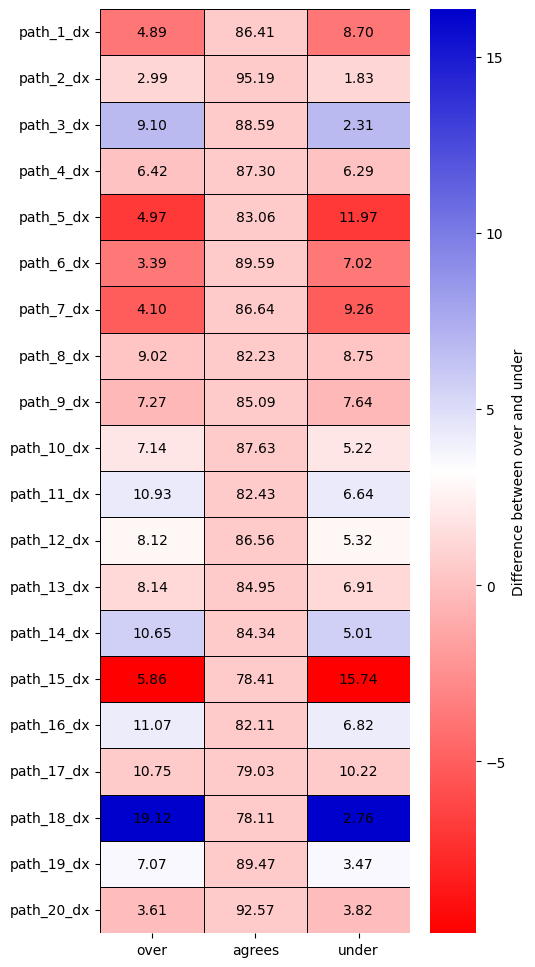

In [60]:
plt.figure(figsize=(5, 12))
sns.heatmap(df_for_overunder_cmap.astype(float), cmap=div_cm, cbar_kws={'label': 'Difference between over and under'}, fmt="d", linewidths=0.5, linecolor='black')

annotate_withoutcommon(over_under_norm)

plt.show()